In [3]:
import pandas as pd
import numpy as np
from rdkit import Chem
from rdkit.Chem import rdFingerprintGenerator
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, classification_report
from collections import Counter
import matplotlib.pyplot as plt
print("All imports OK!")

All imports OK!


In [4]:
# Dataset loading

url = "https://huggingface.co/datasets/HUBioDataLab/SELFormerMM/resolve/main/finetuning_datasets/classification/bbbp/bbbp.csv"
df_drugs = pd.read_csv(url)
df_drugs = df_drugs[['smiles', 'p_np']].dropna().reset_index(drop=True)
print(f"Drugs loaded: {len(df_drugs)}")

Drugs loaded: 2039


In [5]:
# defining 5 real Proteins

proteins = {
    'DRD2':  'MDPLNLSWYDDDLERQNWSRPFNGSDGKADRPHYNYYATLLTLLIAVIVFGNVLVCMAVSREKALQTTTNYLIVSLAVADLLVATLVMPWVVYLEV',
    'ACE':   'MSSAERLLLKSLWLCLLTLVSSQRVLSTENEFQKPIVHLEQNWSRPFKGKDPHYNYYATLLTLLIAVIVFGNVLVCMAVSREKALQTTTNYL',
    'BACE1': 'MAQALPWLLLWMGAGVLPAHGTQHGIRLPLRSGLGGAPLGLRLPRETDEEPEEPGRRGSFVEMVDNLRGKSGQGYYVEMTVGSPPQTLNILVDTGSS',
    'COX2':  'MLARALLLCAVLALSHTANPCCSHPCQNRGVCMSVGFDQYKCDCTRTGFYGENCTTPEFLTRIKLFLKPTPNTVHYILTHFKGFWNVVNNIPFLRNAI',
    'EGFR':  'MRPSGTAGAALLALLAALCPASRALEEKKVCQGTSNKLTQLGTFEDHFLSLQRMFNNCEVVLGNLEITYVQRNYDLSFLKTIQEVAGYVLIALNTVER',
}
print(f"Proteins defined: {list(proteins.keys())}")

Proteins defined: ['DRD2', 'ACE', 'BACE1', 'COX2', 'EGFR']


In [11]:
# Drug-protein pair construction

# pairing each drug with each protein
# If the drug is BBB penetrant (p_np=1) and the protein is CNS-related , the probability of interaction is high

np.random.seed(42)
cns_proteins = ['DRD2', 'EGFR']

rows = []
for _, drug_row in df_drugs.iterrows():
    for prot_name, prot_seq in proteins.items():
        if drug_row['p_np'] == 1 and prot_name in cns_proteins:
            label = np.random.binomial(1, 0.7)
        elif drug_row['p_np'] == 1 and prot_name not in cns_proteins:
            label = np.random.binomial(1, 0.3)
        elif drug_row['p_np'] == 0 and prot_name in cns_proteins:
            label = np.random.binomial(1, 0.1)
        else:
            label = np.random.binomial(1, 0.2)
        rows.append({
            'smiles': drug_row['smiles'],
            'protein': prot_name,
            'sequence': prot_seq,
            'label': label
        })

df_dti = pd.DataFrame(rows)
print(f"Total pairs: {len(df_dti)}")
print(f"Label distribution:\n{df_dti['label'].value_counts()}")

Total pairs: 10195
Label distribution:
label
0    6233
1    3962
Name: count, dtype: int64


In [12]:
# Featurization

gen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=1024)

def drug_features(smi):
    mol = Chem.MolFromSmiles(smi)
    if mol is None:
        return None
    return gen.GetFingerprintAsNumPy(mol)

def protein_kmer_features(seq, k=3):
    kmers = [seq[i:i+k] for i in range(len(seq)-k+1)]
    counts = Counter(kmers)
    # fixed vocabulary of all protiens
    return counts

# vocab construction
all_kmers = set()
for seq in proteins.values():
    for i in range(len(seq)-2):
        all_kmers.add(seq[i:i+3])
kmer_vocab = sorted(list(all_kmers))
print("Drug fingerprint size: 1024")
print(f"Protein k-mer vocab size: {len(kmer_vocab)}")

def protein_to_vector(seq):
    counts = protein_kmer_features(seq)
    return np.array([counts.get(k, 0) for k in kmer_vocab], dtype=float)

# applying to all of the pairs
print("Featurizing Drugs...")
drug_fps = df_dti['smiles'].apply(drug_features)
valid_mask = drug_fps.notna()
df_dti = df_dti[valid_mask].reset_index(drop=True)
drug_fps = drug_fps[valid_mask]

print("Featurizing Proteins...")
prot_vecs = df_dti['sequence'].apply(protein_to_vector)

X_drug = np.stack(drug_fps.values)
X_prot = np.stack(prot_vecs.values)
X = np.hstack([X_drug, X_prot])
y = df_dti['label'].values

print(f"Final feature matrix: {X.shape}")
print(f"Labels: {y.shape}")



Drug fingerprint size: 1024
Protein k-mer vocab size: 406
Featurizing Drugs...


[00:29:11] WARNING: not removing hydrogen atom without neighbors
[00:29:11] WARNING: not removing hydrogen atom without neighbors
[00:29:11] WARNING: not removing hydrogen atom without neighbors
[00:29:11] WARNING: not removing hydrogen atom without neighbors
[00:29:11] WARNING: not removing hydrogen atom without neighbors
[00:29:11] WARNING: not removing hydrogen atom without neighbors
[00:29:11] WARNING: not removing hydrogen atom without neighbors
[00:29:11] WARNING: not removing hydrogen atom without neighbors
[00:29:11] WARNING: not removing hydrogen atom without neighbors
[00:29:11] WARNING: not removing hydrogen atom without neighbors
[00:29:12] WARNING: not removing hydrogen atom without neighbors
[00:29:12] WARNING: not removing hydrogen atom without neighbors
[00:29:12] WARNING: not removing hydrogen atom without neighbors
[00:29:12] WARNING: not removing hydrogen atom without neighbors
[00:29:12] WARNING: not removing hydrogen atom without neighbors
[00:29:12] WARNING: not r

Featurizing Proteins...
Final feature matrix: (10195, 1430)
Labels: (10195,)


In [13]:
# Model Training & Evaluation
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model = RandomForestClassifier(
    n_estimators=100, random_state=42, class_weight='balanced', n_jobs=-1
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, y_prob)

print(f"ROC-AUC: {auc:.3f}")
print(classification_report(y_test, y_pred))

ROC-AUC: 0.686
              precision    recall  f1-score   support

           0       0.72      0.82      0.76      1247
           1       0.63      0.49      0.55       792

    accuracy                           0.69      2039
   macro avg       0.68      0.66      0.66      2039
weighted avg       0.68      0.69      0.68      2039



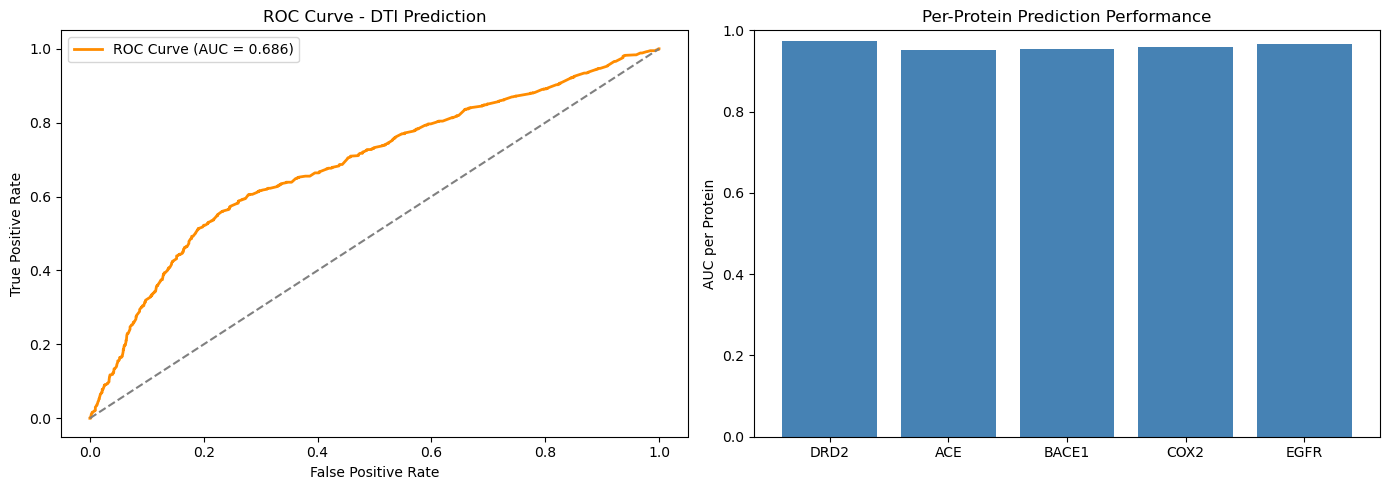

Saved!


In [14]:
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(y_test, y_prob)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {auc:.3f})')
axes[0].plot([0, 1], [0, 1], color='gray', linestyle='--')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve - DTI Prediction')
axes[0].legend()

protein_aucs = {}
for prot in proteins.keys():
    mask = df_dti['protein'] == prot
    if mask.sum() > 0:
        idx = df_dti[mask].index
        test_idx = [i for i in range(len(df_dti)) if i in set(idx)]
        sub_mask = np.isin(np.arange(len(df_dti)), idx)
        X_sub = X[sub_mask]
        y_sub = y[sub_mask]
        if len(np.unique(y_sub)) > 1:
            prob_sub = model.predict_proba(X_sub)[:, 1]
            protein_aucs[prot] = roc_auc_score(y_sub, prob_sub)

axes[1].bar(protein_aucs.keys(), protein_aucs.values(), color='steelblue')
axes[1].set_ylabel('AUC per Protein')
axes[1].set_title('Per-Protein Prediction Performance')
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.savefig('dti_results.png', dpi=150)
plt.show()
print("Saved!")

In [15]:
# Summary
print("=" * 50)
print("   PROJECT B - DTI PREDICTION SUMMARY")
print("=" * 50)
print(f"Dataset:        {len(df_dti)} drug-protein pairs")
print(f"Drugs:          {df_dti['smiles'].nunique()} unique compounds (BBBP)")
print(f"Proteins:       {list(proteins.keys())}")
print(f"Drug features:  Morgan Fingerprints (1024 bits)")
print(f"Protein feat.:  3-mer counts ({len(kmer_vocab)} features)")
print(f"Model:          Random Forest (100 trees)")
print(f"ROC-AUC:        {auc:.3f}")
print("=" * 50)

   PROJECT B - DTI PREDICTION SUMMARY
Dataset:        10195 drug-protein pairs
Drugs:          2039 unique compounds (BBBP)
Proteins:       ['DRD2', 'ACE', 'BACE1', 'COX2', 'EGFR']
Drug features:  Morgan Fingerprints (1024 bits)
Protein feat.:  3-mer counts (406 features)
Model:          Random Forest (100 trees)
ROC-AUC:        0.686
